#### Air polution prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import keras
from keras.preprocessing import timeseries_dataset_from_array

In [3]:
# Zadanie 1

# Read CSV file - skip columns mentioned in exercise
cols_to_skip = ["No", "wd", "station"]
df = pd.read_csv("PRSA_Data_Wanshouxigong_20130301-20170228.csv", usecols=lambda x: x not in cols_to_skip)

# Create Date column based on existing data from df, set it as index, then drop cols
timeframe_cols = ["year", "month", "day", "hour"]
df["Date"] = pd.to_datetime(df[timeframe_cols])

df = df.set_index("Date")
df = df.drop(labels=timeframe_cols, axis=1)
df.index.freq = "h"

# Interpretation of data: 
# Each row is an hour ranging from 2013-03-01 up to 2017-02-28 (35064 records)

# PM2.5 - microscopic airborne particles (2.5 micrometer diameter) - very easily penetrates the lungs during inhalation and enters bloodstream, one of the most important marker of air polution (µg/m³).
# PM10 - microscopic airborne particles (10 micrometers diameter)  - slightly bigger polutants like mold, dust, soot, can induce adverse health effects (µg/m³). 
# SO2  - Sulfur dioxide concentration in the air (µg/m³).
# NO2 - Nitrogen Dioxide concentration in the air (µg/m³).
# CO - Carbon Monoxide concentration in the air (µg/m³).
# O3 - Ozone concentration in the air (µg/m³).
# TEMP - Temperature in Celcius (C') at given time.
# PRES - Pressure i hectopascal (hPa) at given time.
# DEWP - Dewpoint Temp - the temperature point at which the air can hold no more water (water vapor).
# RAIN - Rain level (millimeters) at given time.
# WSPM - Wind speed (m/s) at given time.

In [4]:
# Zadanie 2

# Start by showcasing means, stds, and largest and the smallest values from the columns.
df.describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


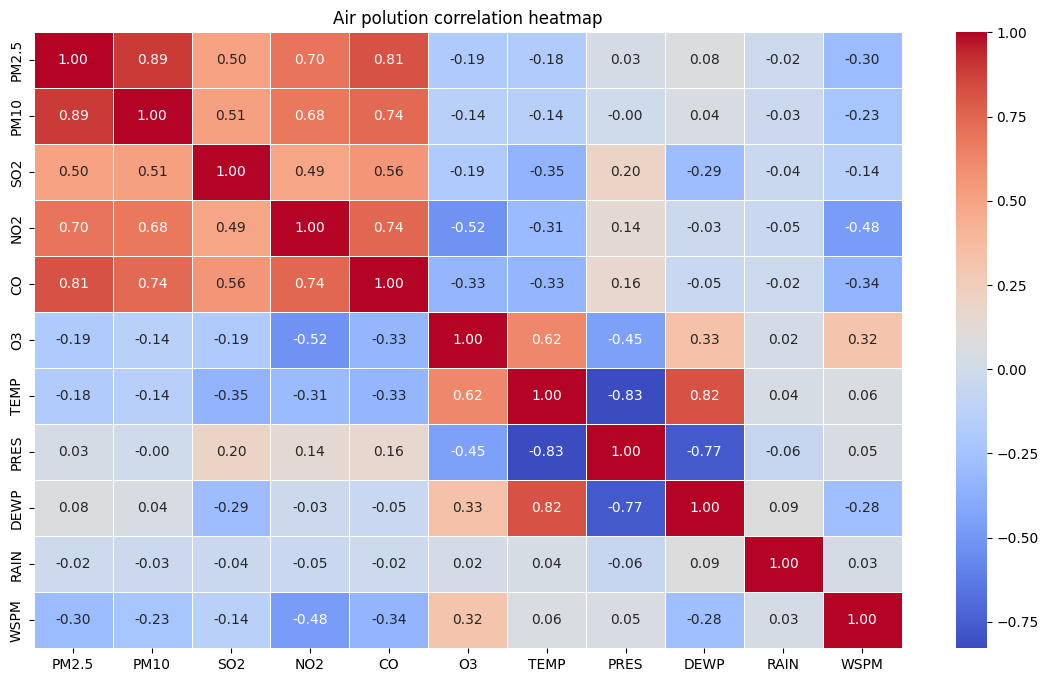

In [5]:
corr_matrix = df.corr(method="pearson")

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Air polution correlation heatmap")
plt.show()

# At first glace we can observe very strong correlations sector in the upper left corner. Concentration of polution gases (CO, NO2, SO2) correlates very high with both PM2.5 and PM10.
# Temperature highly correlates with with DEWP, as DEWP informs us if air can store any more water (Seems like collinearity - those two features holds similar information).
# In general - all weather related features has strong correlations - PRESS/TEMP (-0.83) or PRESS/DEWP (-0.77) - it has to be taken into consideration during feature engineering.

# There is negative correlation (-0.30) of wind speed and pm2.5 and (-0.23) to pm10. That shows us windier times
# can deacrease the level of polution, and staler parts of the day/month/year are expected to have higher PMs concentrations. 
# The same can be said about temperature, but in smaller size (-0.18) for TEMP/PM2.5 and (-0.14) for TEMP/PM10.

<Axes: ylabel='PM2.5'>

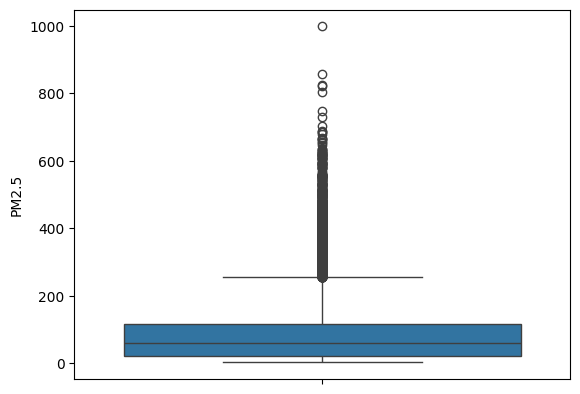

In [6]:
sns.boxplot(df["PM2.5"])


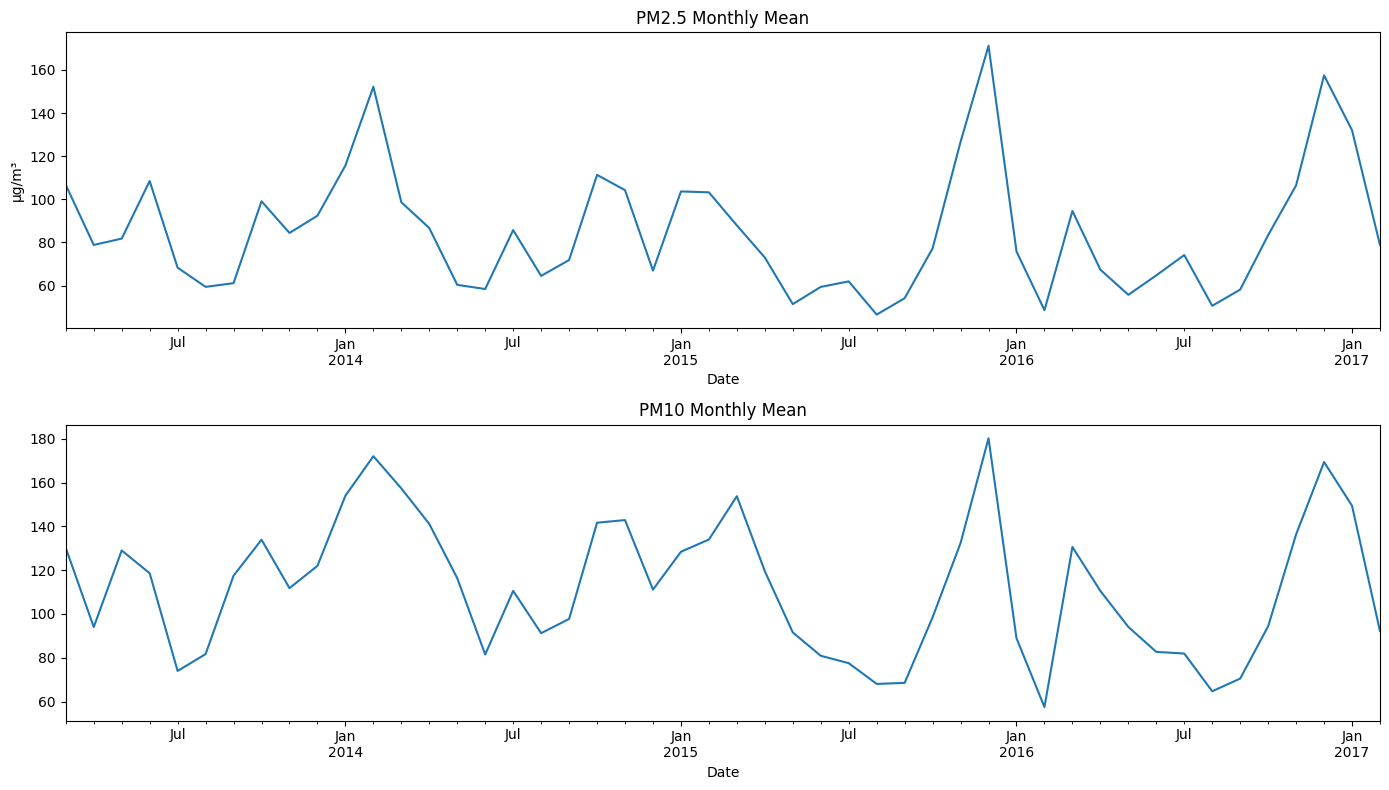

In [7]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(14,8))

# Decided for better readability to convert data from hourly to monthly using mean
df["PM2.5"].resample("ME").mean().plot(ax=ax1)
df["PM10"].resample("ME").mean().plot(ax=ax2)

ax1.set_title("PM2.5 Monthly Mean")
ax1.set_ylabel("µg/m³")

ax2.set_title("PM10 Monthly Mean")
ax1.set_ylabel("µg/m³")

plt.tight_layout()
plt.show()

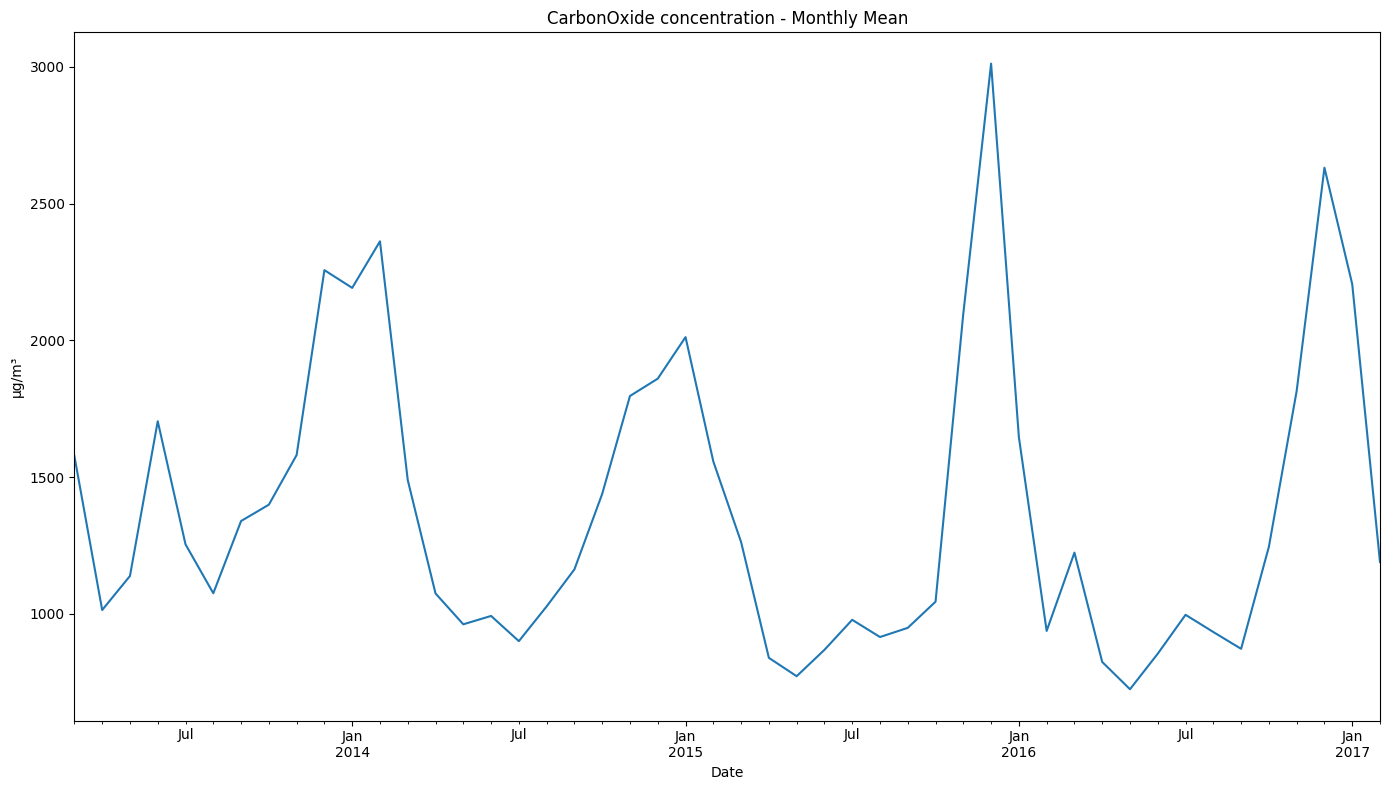

In [8]:
# Plot how Te
fig, ax1 = plt.subplots(1,1, figsize=(14,8))
df["CO"].resample("ME").mean().plot(ax=ax1)

ax1.set_title("CarbonOxide concentration - Monthly Mean")
ax1.set_ylabel("µg/m³")

plt.tight_layout()
plt.show()

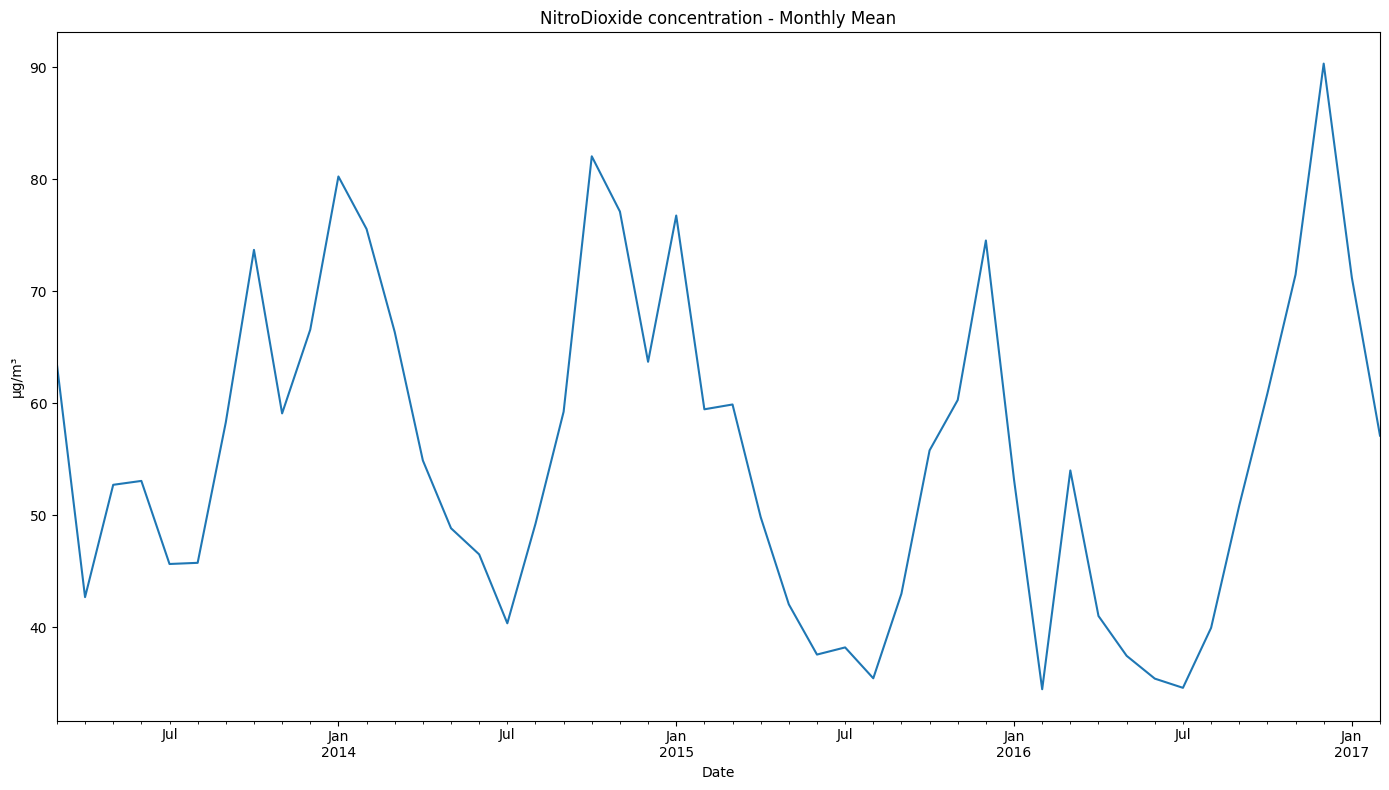

In [9]:
fig, ax1 = plt.subplots(1,1, figsize=(14,8))
df["NO2"].resample("ME").mean().plot(ax=ax1)

ax1.set_title("NitroDioxide concentration - Monthly Mean")
ax1.set_ylabel("µg/m³")

plt.tight_layout()
plt.show()

#### Quick note: 

> What we observed in correlation matrix can be easily seen on the charts. The periods where PM2.5 and PM10 spikes, the CO & NO2 levels are high as well. 
Especially january 2016 - we can observe record spike in CO concentration, and record in both PM2.5 and PM10.

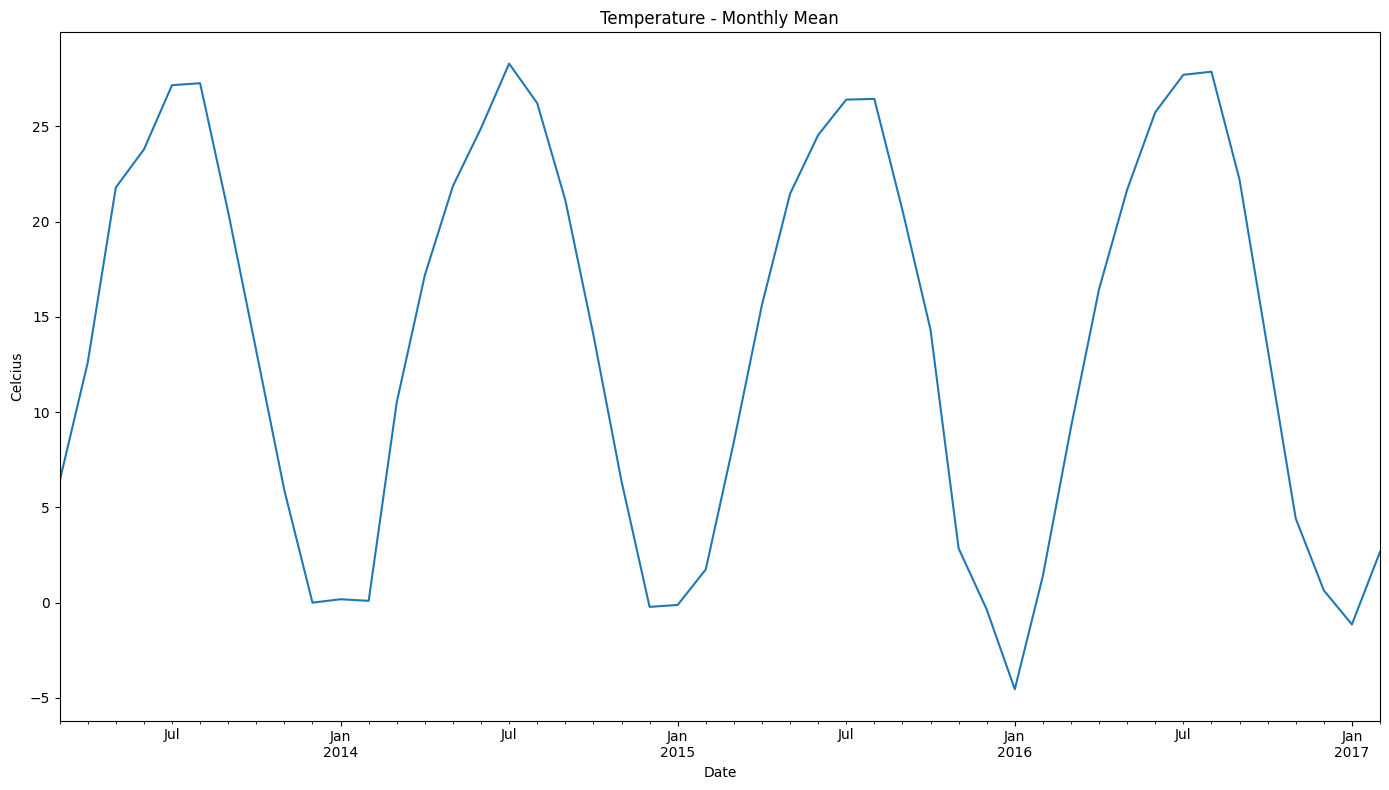

In [10]:
# Plot how Temperature is structured across whole period - we can observe very consistent trends. 
# No deviations from the norm - weather trends seems to repeat in predictible manner.
fig, ax1 = plt.subplots(1,1, figsize=(14,8))
df["TEMP"].resample("ME").mean().plot(ax=ax1)

ax1.set_title("Temperature - Monthly Mean")
ax1.set_ylabel("Celcius")

plt.tight_layout()
plt.show()

#### PM2.5 vs time of the day
> The most polluted times of the day are between 15:00 and 00:00 - we can see that PM2.5 concentration is rising rapidly in this time frame - this can be beneficial information during model creation and feature engineering - part of the day can be a strong predictor for PM2.5 concentration.

Text(0.5, 0, 'Hour of the day')

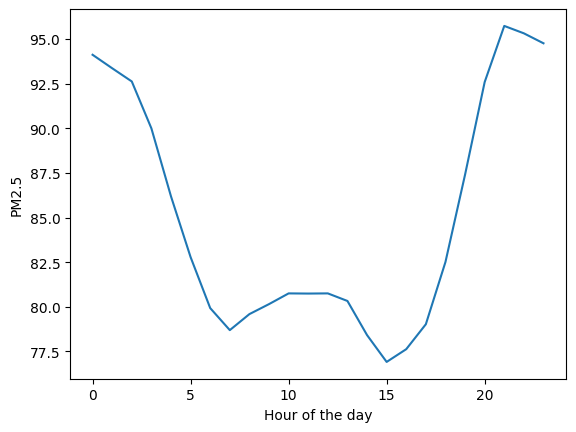

In [11]:
groupped_hourly_df = df.groupby(by=df.index.hour)["PM2.5"].mean()
sns.lineplot(data=groupped_hourly_df).set_xlabel("Hour of the day")

#### PM2.5 vs day of week

> Monday is the cleanest day of the week. Pollution on average starts increasing on thurdays and has its peak on saturday. Then after that it starts to lower and cycles repeats. It holds information too -> if the day is between thursday and saturday we can expect the PM2.5 to be higher, and as well periods between sundays and thursdays could characterize with lower values of PM2.5.

Text(0.5, 0, 'Day of the week')

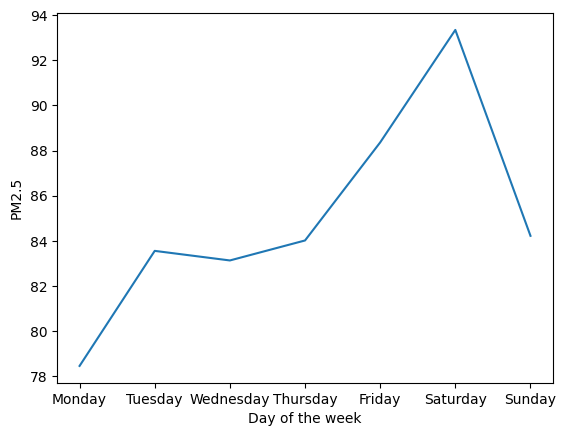

In [12]:
days_of_the_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

groupped_hourly_df = df.groupby(by=df.index.day_name())["PM2.5"].mean()
groupped_hourly_df = groupped_hourly_df.reindex(days_of_the_week)

sns.lineplot(data=groupped_hourly_df).set_xlabel("Day of the week")

#### PM2.5 vs month

> Knowing month of the year we can make an assumption - colder parts of the year beginning from september has higher polution rate. During hotter months starts from march we observe sharp decrease of the level of PM2.5 and its lowest levels during holidays period which are the hottest months of the year. This also confirms the data plotted on general PM2.5 level across all the time frame.

Text(0.5, 0, 'Month')

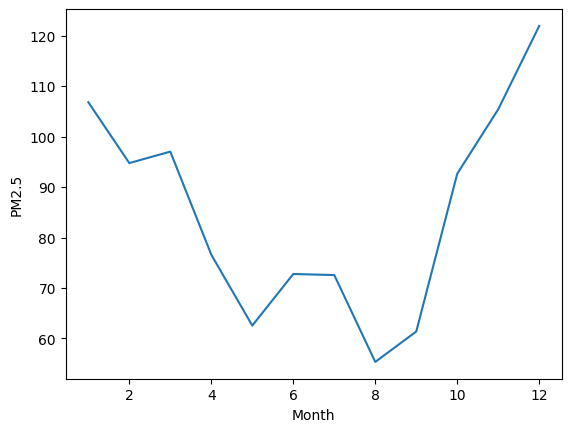

In [13]:
groupped_hourly_df = df.groupby(by=df.index.month)["PM2.5"].mean()
sns.lineplot(data=groupped_hourly_df).set_xlabel("Month")

In [14]:
# Zadanie 3

# Drop all records where we miss pm2.5 
df.dropna(subset=['PM2.5'], inplace=True)

# Interpolation on missing data
df.interpolate(method='time', inplace=True)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34368 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   34368 non-null  float64
 1   PM10    34368 non-null  float64
 2   SO2     34368 non-null  float64
 3   NO2     34368 non-null  float64
 4   CO      34368 non-null  float64
 5   O3      34368 non-null  float64
 6   TEMP    34368 non-null  float64
 7   PRES    34368 non-null  float64
 8   DEWP    34368 non-null  float64
 9   RAIN    34368 non-null  float64
 10  WSPM    34368 non-null  float64
dtypes: float64(11)
memory usage: 3.1 MB


In [15]:
# Feature engineering for cyclical data can be done by this paper method: https://arxiv.org/html/2512.03656v1
def calc_sin_and_cos(f: int, time_cycle: int) -> tuple[float, float]:
    """
    As above provided link to the paper states, the observations can be cyclical encoded.
    This resolves the problem that time like 23:00 and 00:00 numericly are very separated, but time frame wise 
    they are the closest neighbours. Authors suggested such feature engineering as best practice in time frame data 
    
    Args:
        f - current observation
        time_cycle: number of unique values in specific period: 
            24 hours in a day, 
            7 days in a week, 
            12 months in a year
    """
    
    sin_val = np.sin(2*np.pi * f / time_cycle)
    cos_val = np.cos(2* np.pi * f / time_cycle)
    return sin_val, cos_val

df["hour_sin"], df["hour_cos"] = calc_sin_and_cos(f=df.index.hour, time_cycle=24)
df["day_sin"], df["day_cos"] = calc_sin_and_cos(f=df.index.day_of_week, time_cycle=7)
df["month_sin"], df["month_cos"] = calc_sin_and_cos(f=df.index.month, time_cycle=12)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34368 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PM2.5      34368 non-null  float64
 1   PM10       34368 non-null  float64
 2   SO2        34368 non-null  float64
 3   NO2        34368 non-null  float64
 4   CO         34368 non-null  float64
 5   O3         34368 non-null  float64
 6   TEMP       34368 non-null  float64
 7   PRES       34368 non-null  float64
 8   DEWP       34368 non-null  float64
 9   RAIN       34368 non-null  float64
 10  WSPM       34368 non-null  float64
 11  hour_sin   34368 non-null  float64
 12  hour_cos   34368 non-null  float64
 13  day_sin    34368 non-null  float64
 14  day_cos    34368 non-null  float64
 15  month_sin  34368 non-null  float64
 16  month_cos  34368 non-null  float64
dtypes: float64(17)
memory usage: 4.7 MB


In [16]:
# Zadanie 4
X = df.drop(columns=["PM2.5"]).values
y = df["PM2.5"].values

try: 
    assert len(X) == len(y)
except AssertionError:
    print("Different sizes of X and y arrays")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=False)

input_scaler = StandardScaler()
target_scaler = StandardScaler()

input_scaler.fit(X_train)
X_train_scaled = input_scaler.transform(X_train)
X_test_scaled = input_scaler.transform(X_test)

y_train_reshaped = y_train.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

target_scaler.fit(y_train_reshaped) 
y_train_scaled = target_scaler.transform(y_train_reshaped)
y_test_scaled = target_scaler.transform(y_test_reshaped)

# Try different batch sizes from 64 up to 256
batch_size = 128
sequence_length = 24
n_features = X_train.shape[1]

gen_train = timeseries_dataset_from_array(data=X_train_scaled, targets=y_train_scaled, batch_size=batch_size, sequence_length=sequence_length)
gen_test = timeseries_dataset_from_array(data=X_test_scaled, targets=y_test_scaled, batch_size=batch_size, sequence_length=sequence_length)

2026-05-26 20:58:40.017225: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-26 20:58:40.017265: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-26 20:58:40.017269: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1779821920.017491  855736 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779821920.017666  855736 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [17]:
# Zadanie 5

model = keras.models.Sequential([
    keras.layers.Input(shape=(sequence_length, n_features)),
    keras.layers.LSTM(128,return_sequences=True),
    keras.layers.Dropout(rate=0.3),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(rate=0.3),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(rate=0.3),
    keras.layers.LSTM(8, return_sequences=False),
    keras.layers.Dense(1, activation="linear"),
])

lr = 1e-3
opt = keras.optimizers.RMSprop(learning_rate=lr)

model.compile(optimizer=opt, loss='mse', metrics=['r2_score'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,385 (536.66 KB)

 Trainable params: 137,385 (536.66 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Zadanie 6
n_epochs = 50

fit = model.fit(
    gen_train, 
    validation_data=gen_test, 
    epochs=n_epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ]
    )

Epoch 1/50


2026-05-26 20:58:40.679388: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


242/242 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.4630 - r2_score: 0.5373 - val_loss: 1.1079 - val_r2_score: 0.4774
Epoch 2/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3291 - r2_score: 0.6711 - val_loss: 0.6953 - val_r2_score: 0.6720
Epoch 3/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2439 - r2_score: 0.7562 - val_loss: 0.4327 - val_r2_score: 0.7959
Epoch 4/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1933 - r2_score: 0.8069 - val_loss: 0.3473 - val_r2_score: 0.8362
Epoch 5/50
186/242 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2073 - r2_score: 0.7748

KeyboardInterrupt: 

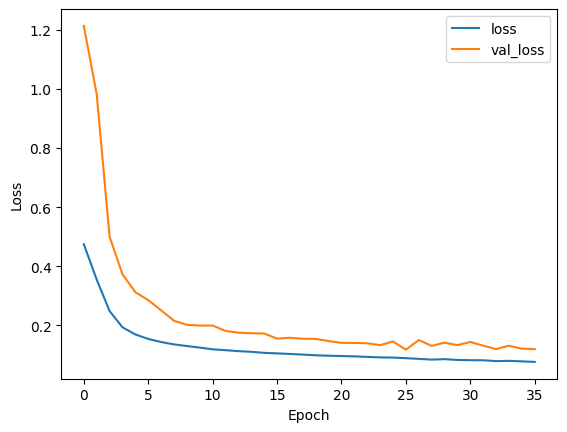

In [ ]:
plt.plot(fit.history['loss'], label='loss')
plt.plot(fit.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel('Loss')
plt.legend()
plt.show()

First run: epochs: 100 - No dropouts at all in model after LSTM layers, default Adam optimizer settings: final val loss 0.12

<img src="runs_plots/1st_run.jpg" width="700" alt="Air polution first run">

Second run: epochs: 50 - I added dropout 0.2, after each LSTM layer, default Adam optimizer settingsL final val loss 0.15, but graph was very spiky and peaked multiple times during training what may suggested that learning rate was too high.

<img src="runs_plots/2nd_run.jpg" width="700" alt="Air polution second run">

Third run: epochs: 100 - Dropout 0.2 after each LSTM, Adam Optimizer lr: 0.001 - Model went through all 100 epochs but ended on the worst val loss ~ 0.20 and the gap between loss and val loss was the highest of all runs. 

<img src="runs_plots/3rd_run.jpg" width="700" alt="Air polution third run">

Fourth run: epochs: 100 - I decided to try delete dropout layer before dense layer and kept dropout only after 1st and 2nd LSTM layer. Still val los around ~ 0.2 and pretty big gap between train and test set val loss which indicates overfitting.

<img src="runs_plots/4th_run.jpg" width="700" alt="Air polution fourth run">

Fifth run: Epochs: 100 (stopped after 68th by early stopping) - Optimizer Adam with lr: 1e-4.
I decided to try to reduce droput in each layer from 0.2 to 0.1 - This created very unstable and very overfitted model. Terrible run

<img src="runs_plots/5th_run.jpg" width="700" alt="Air polution fifth run">

At this time: best run was the 1st run with model architecutre:

```python 
model = keras.models.Sequential([
    keras.layers.Input(shape=(sequence_length, n_features)),
    keras.layers.LSTM(128,return_sequences=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(8, return_sequences=False),
    keras.layers.Dense(1, activation="linear"),
])
```

Sixth run: I changed architecture of the model: 

50 epochs (stopped after 42) Adam optimizer with lr 1e3.
I added one more LSTM layer: 128 -> 64 -> 32 -> 8 -> Dense layer w/ linear func

Best val los, similar to 1st run: around 0.12. Bigger neural network gets similar result to less comples one.

<img src="runs_plots/6th_run.jpg" width="700" alt="Air polution sixth run">

7th run: **Big breakthroug**

50 epochs (stopped after 32 due to EarlyStopping) Adam optimizer lr 1e-3, 4 LSTM layers with droput layer after each with 0.3 rate. First phase of training was a bit spiky and chaotic but later part shows great improvment in fitting model and decent val loss ~ 0.1

I changed batch size from 64 to 128 - this improved time per epoch from 10 to 5 seconds without decreasing val loss.
On the other hand 256 batch size made 3sec per epoch but model was unstable.

Best params: 
Adam optimizer lr 1e-3, 
Batch size 128,

> LSTM Neural network architecture
```python
model = keras.models.Sequential([
    keras.layers.Input(shape=(sequence_length, n_features)),
    keras.layers.LSTM(128,return_sequences=True),
    keras.layers.Dropout(rate=0.3),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(rate=0.3),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(rate=0.3),
    keras.layers.LSTM(8, return_sequences=False),
    keras.layers.Dense(1, activation="linear"),
])
```

<img src="runs_plots/7th_run.jpg" width="700" alt="Air polution seventh run">

8th run: I decided to switch optimizers from Adam to RMSPROP.

I did two runs to compare learning rates.
**1e-3 lr**
<br>
RMSPROP optimizer seems to have smoother training. There are no such spikes like using Adam optimizer. Although both final val loss seems to be very close (both around 0.12) RMSPROP has slight edge with training plot not jumping as much as Adam.
<br>
<img src="runs_plots/rmsprop_1st_run_lr1e-3.png" width="700" alt="Air polution using RMSPROP opt run">

<br>
**1e-4 lr**
<br>
Run with smaller learnig rate gets worse outcomes - better keeping lr 1e-3
<br>
<img src="runs_plots/rmsprop_2nd_run_lr1e-4.png" width="700" alt="Air polution using RMSPROP opt run">




In [ ]:
train_mse, train_r2 = model.evaluate(gen_train)
test_mse, test_r2 = model.evaluate(gen_test)

print(f"Train Evaluation: MSE: {train_mse}  R2: {train_r2}")
print(f"Test Evaluation: MSE: {test_mse}  R2: {test_r2}")

train_preds = model.predict(gen_train)
test_preds = model.predict(gen_test)

train_preds = target_scaler.inverse_transform(train_preds)
test_preds = target_scaler.inverse_transform(test_preds)

inversed_y_train = target_scaler.inverse_transform(y_train_scaled)
inversed_y_test = target_scaler.inverse_transform(y_test_scaled)

mse_score_train = mean_squared_error(y_true=inversed_y_train[sequence_length-1:], y_pred=train_preds)
mse_score_test = mean_squared_error(y_true=inversed_y_test[sequence_length-1:], y_pred=test_preds)

r2_score_train = r2_score(y_true=inversed_y_train[sequence_length-1:], y_pred=train_preds)
r2_score_test = r2_score(y_true=inversed_y_test[sequence_length-1:], y_pred=test_preds)


print(f"Computed metrics MSE: train {mse_score_train}  test {mse_score_test}")
print(f"RMSE train: {np.sqrt(mse_score_train)}  test: {np.sqrt(mse_score_test)}")

print(f"Computed metrics R2: train {r2_score_train}  test {r2_score_test}")

242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1026 - r2_score: 0.8975
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1176 - r2_score: 0.9445
Train Evaluation: MSE: 0.10260485112667084  R2: 0.8974608182907104
Test Evaluation: MSE: 0.11757886409759521  R2: 0.9445422291755676
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Computed metrics MSE: train 7896.695390131845  test 14935.728187704288
RMSE train: 88.86335234578901  test: 122.21181689061123
Computed metrics R2: train -0.20172596322560943  test -0.06998975198580482


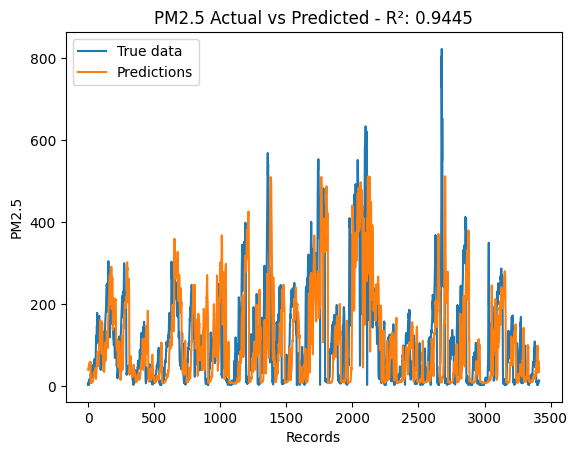

In [ ]:
plt.plot(inversed_y_test[sequence_length-1:], label='True data')
plt.plot(test_preds, label='Predictions')
plt.xlabel("Records")
plt.ylabel('PM2.5')
plt.title(f"PM2.5 Actual vs Predicted - R²: {test_r2:.4f}")
plt.legend()
plt.show()

#### Discussion

The model seems to works well in predicting general trend in chaning air polution marker (PM2.5). The hardest task is to predict this rapid and vert spiky peaks in polution. Model generalize well but such extreme deviations are still biggest issue. 

Model can explain about 93% of variance of testing set, which is very good outcome.

Dropping columns vs interpolation: After dropping columns with missing PM2.5 values, the total amount of records with null values in some columns was only around 3% of whole dataset - dropping 3% from 34k records seemed to be not very aggresive strategy in terms of losing the data, but still I chose data imputation with interpolation to avoid having more empty spaces between records.

I tried training model on different batch sizes - my current setup allows TensorFlow to utilize GPU acceleration which speeds up matrix computations. Given this, bigger batches of data means faster training per epoch.
Batch size 64 took 10sec per epoch
Batch size 128 took 5sec per epoch 
Batch size 256 took 3sec per epoch, but here i noticed that my val_score on test set starts to drop, so despite faster computation, the loss of model precision guides me to select final batch size of 128 which was good compromise between speed and precision.

During searching of model configuration i observed a lot of my first architectures was overfitting even with dropouts.
I was working only with 3 layers of LSTM 128-32-8 then Dense layer, and to improve quality of model predictions i decided to add one more layer in the middle of neural network. Decision was based on big params amount in the first layer, and i didn't want to double it adding one big new layer of LSTM 256 in the front of the network. I went with LSTM 64 in the middle and applied droputs after each LSTM layer. The training with such architecture was more predictable and gave me best outcomes.

Also adding wind direction variable creates bigger dataset dimensionality given the fact that encoding stategy for this kind of data has to be applied, which only makes data more complex without inputing more valuable information to model. Dropping column completly seems to be the optimal strategy preventing inflating of features amount and data complexity.

Optimizers: No matter the Optimizer choice I tested to learning rates: 0.001 and 0.0001 (1e-3 vs 1e-4). In both optimizers Adam & RMSPROP i observed smaller learning rate of 1e-4 ended up with worse results giving higher ending value of val_loss and bigger overfitting of the model. So i stick with 1e-3 (0.001). As i mentioned during training session descriptions both optimizers seems to provide similar val losses, the RMSPROP training goes smoother and is more predictable than Adam.